# ADY2026 — U.S. Housing Price Prediction Pipeline 🏠

**Course Project** | Full End-to-End Data Science & Machine Learning Pipeline

---

| # | Rubric Criterion | Notebook Section |
|---|---|---|
| 2 | Problem Understanding | Section 1 |
| 3 | Data Understanding & Preprocessing | Section 2 |
| 4 | SQL Analysis | Section 3 |
| 5 | Python Analysis | Section 4 |
| 6 | Visualization | Section 5 |
| 7 | Regression Analysis | Section 6 |

---

## 0. Environment Setup

In [85]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import sqlite3
import math
from pathlib import Path

# Visualization
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

# Notebook display
from IPython.display import display

# Paths — adjust if your notebook is not inside notebook/
PROJECT_ROOT = Path("..").resolve()
RAW_FILE     = PROJECT_ROOT / "data" / "raw" / "Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv"

print(f"Project Root  : {PROJECT_ROOT}")
print(f"Raw Data File : {RAW_FILE}")
print(f"File exists?  : {RAW_FILE.exists()}")

Project Root  : D:\Data\Programming\Python\ady-spring2026
Raw Data File : D:\Data\Programming\Python\ady-spring2026\data\raw\Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv
File exists?  : True


---

## 1. Problem Understanding (Rubric #2)

### Objective
Predict **monthly housing price changes** across ~900 U.S. Metropolitan Statistical Areas (MSAs)
using the **Zillow Home Value Index (ZHVI)** dataset.

### Why predict Log-Returns instead of raw prices?
| Benefit | Explanation |
|---|---|
| **Stationarity** | Raw prices trend upward; log-returns fluctuate around zero — better for ML |
| **Scale-invariance** | A \$10K swing in San Jose (\$1.5M) vs Clarksdale (\$50K) are very different proportionally |
| **Additivity** | Monthly log-returns can be summed to get cumulative returns |
| **Reversibility** | Convert back anytime: `price_t = price_{t-1} × exp(log_return)` |

### Feature Engineering Strategy
We create **lag features** — the target value shifted by 1, 2, 3, 6, and 12 months — to let
the model learn from recent momentum and seasonal patterns.

---

## 2. Data Understanding & Preprocessing (Rubric #3)

### Step 2.1 — Load Raw Data

In [86]:
# Load the raw Zillow ZHVI CSV (wide format: one column per month)
raw = pd.read_csv(RAW_FILE, low_memory=False, skipinitialspace=True)
raw.columns = raw.columns.str.strip()

# Clean string columns
for col in raw.select_dtypes(["object"]).columns:
    raw[col] = raw[col].str.strip()

# Keep only MSA (Metropolitan Statistical Area) rows
raw = raw[raw["RegionType"] == "msa"].reset_index(drop=True)

print(f"Raw shape after filtering MSAs: {raw.shape}")
print(f"Number of unique regions: {raw['RegionName'].nunique()}")
print(f"Sample region names: {raw['RegionName'].head(5).tolist()}")

Raw shape after filtering MSAs: (894, 318)
Number of unique regions: 894
Sample region names: ['New York, NY', 'Los Angeles, CA', 'Chicago, IL', 'Dallas, TX', 'Houston, TX']


### Step 2.2 — Melt: Wide → Long Format

The raw data has **one column per month** (e.g., `2000-01-31`, `2000-02-29`, ...).
We melt this into a proper time-series format: one row = one region × one month.

In [87]:
META_COLS  = ["RegionID", "SizeRank", "RegionName", "RegionType", "StateName"]
date_cols  = [c for c in raw.columns if c not in META_COLS]
keep_meta  = ["RegionID", "RegionName", "StateName"]

df = raw[keep_meta + date_cols].melt(
    id_vars=keep_meta,
    value_vars=date_cols,
    var_name="date",
    value_name="price"
)
df["date"]  = pd.to_datetime(df["date"])
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df = df.sort_values(["RegionID", "date"]).reset_index(drop=True)

print(f"Long-format shape  : {df.shape}")
print(f"Missing prices     : {df['price'].isna().sum():,}")
print(f"Date range         : {df['date'].min().date()} → {df['date'].max().date()}")

Long-format shape  : (279822, 5)
Missing prices     : 49,266
Date range         : 2000-01-31 → 2026-01-31


### Step 2.3 — Handle Missing Values

We interpolate missing prices **within each region** using time-based interpolation,
then forward-fill and backward-fill any remaining edge cases.

In [88]:
def interpolate_region(grp):
    """Interpolate missing prices for a single region."""
    grp = grp.copy().set_index("date")
    grp["price"] = (
        grp["price"]
        .interpolate(method="time", limit_direction="both")
        .ffill().bfill()
    )
    return grp.reset_index()

missing_before = df["price"].isna().sum()
df = (
    df.groupby("RegionID", group_keys=False)
    .apply(interpolate_region)
    .reset_index(drop=True)
)
missing_after = df["price"].isna().sum()

print(f"Missing values: {missing_before:,} → {missing_after:,}")

Missing values: 49,266 → 0


### Step 2.4 — Compute Target (Log-Return) and Lag Features

In [89]:
# Compute log-return: ln(price_t / price_{t-1})
df["log_return"] = (
    df.groupby("RegionID")["price"]
    .transform(lambda s: np.log(s / s.shift(1)))
)

# Drop first observation per region (NaN log_return)
rows_before = len(df)
df = df.dropna(subset=["log_return"]).reset_index(drop=True)
print(f"Dropped {rows_before - len(df):,} first-observation rows (NaN log_return)")

# Compute lag features
LAG_PERIODS = [1, 2, 3, 6, 12]

def add_lags(grp):
    """Add lagged log_return features for a single region."""
    grp = grp.copy().sort_values("date")
    for lag in LAG_PERIODS:
        grp[f"lag_{lag}"] = grp["log_return"].shift(lag)
    return grp

df = (
    df.groupby("RegionID", group_keys=False)
    .apply(add_lags)
    .reset_index(drop=True)
)

# Drop warm-up rows where lags are NaN
lag_cols = [f"lag_{p}" for p in LAG_PERIODS]
rows_before = len(df)
df = df.dropna(subset=lag_cols).reset_index(drop=True)
print(f"Dropped {rows_before - len(df):,} warm-up rows (lag NaNs)")
print(f"Final dataset shape: {df.shape}")

Dropped 894 first-observation rows (NaN log_return)
Dropped 10,728 warm-up rows (lag NaNs)
Final dataset shape: (268200, 11)


### Step 2.5 — Chronological Train/Test Split (80/20)

We split by **time**, not randomly, to prevent data leakage.

In [90]:
TRAIN_RATIO = 0.80
all_dates   = df["date"].sort_values().unique()
cutoff_date = all_dates[int(len(all_dates) * TRAIN_RATIO)]

train_df = df[df["date"] <  cutoff_date].copy().reset_index(drop=True)
test_df  = df[df["date"] >= cutoff_date].copy().reset_index(drop=True)

print(f"Cutoff date : {pd.Timestamp(cutoff_date).date()}")
print(f"Train size  : {len(train_df):,} rows ({len(train_df)/len(df):.1%})")
print(f"Test size   : {len(test_df):,} rows ({len(test_df)/len(df):.1%})")

Cutoff date : 2021-02-28
Train size  : 214,560 rows (80.0%)
Test size   : 53,640 rows (20.0%)


### Step 2.6 — City Target Encoding + Scaling

We encode city identity as the **mean target value per city** (fitted on train only)
and optionally scale features with `StandardScaler`.

In [91]:
# City target encoding — fit on train only to avoid leakage
city_mean   = train_df.groupby("RegionID")["log_return"].mean()
global_mean = train_df["log_return"].mean()

train_df["city_enc"] = train_df["RegionID"].map(city_mean)
test_df["city_enc"]  = test_df["RegionID"].map(city_mean).fillna(global_mean)

# Define feature columns
feature_cols = lag_cols + ["city_enc"]

print(f"Features    : {feature_cols}")
print(f"Target      : log_return")
print(f"\nTrain sample:")
display(train_df[["date", "RegionName", "StateName", "price", "log_return"] + feature_cols].head(5))

Features    : ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'city_enc']
Target      : log_return

Train sample:


,date,RegionName,StateName,price,log_return,lag_1,lag_2,lag_3,lag_6,lag_12,city_enc
0,2001-02-28,"Aberdeen, SD",SD,125066.417884,0.0,0.0,0.0,0.0,0.0,0.0,0.001444
1,2001-03-31,"Aberdeen, SD",SD,125066.417884,0.0,0.0,0.0,0.0,0.0,0.0,0.001444
2,2001-04-30,"Aberdeen, SD",SD,125066.417884,0.0,0.0,0.0,0.0,0.0,0.0,0.001444
3,2001-05-31,"Aberdeen, SD",SD,125066.417884,0.0,0.0,0.0,0.0,0.0,0.0,0.001444
4,2001-06-30,"Aberdeen, SD",SD,125066.417884,0.0,0.0,0.0,0.0,0.0,0.0,0.001444


---

## 3. SQL Analysis (Rubric #4)

We load the data into an **in-memory SQLite3 database** and run analytical queries.
Since SQLite lacks `MEDIAN`, `STDDEV`, `CORR`, and `YEAR()`, we register custom implementations.

In [92]:
# ── Custom SQLite Aggregate Functions ─────────────────────────────────────────
class _Median:
    def __init__(self): self._v = []
    def step(self, x):
        if x is not None: self._v.append(x)
    def finalize(self):
        if not self._v: return None
        s = sorted(self._v); n = len(s)
        return (s[n//2-1] + s[n//2]) / 2 if n % 2 == 0 else s[n//2]

class _Stddev:
    def __init__(self): self._v = []
    def step(self, x):
        if x is not None: self._v.append(x)
    def finalize(self):
        n = len(self._v)
        if n < 2: return None
        m = sum(self._v) / n
        return math.sqrt(sum((xi - m)**2 for xi in self._v) / (n - 1))

class _Corr:
    def __init__(self): self._x = []; self._y = []
    def step(self, x, y):
        if x is not None and y is not None:
            self._x.append(x); self._y.append(y)
    def finalize(self):
        if len(self._x) < 2: return None
        return float(np.corrcoef(self._x, self._y)[0, 1])

# ── Build in-memory database ─────────────────────────────────────────────────
combined_df = pd.concat([train_df, test_df], ignore_index=True)
con = sqlite3.connect(":memory:")
combined_df.to_sql("housing", con, index=False, if_exists="replace")
con.create_aggregate("MEDIAN", 1, _Median)
con.create_aggregate("STDDEV", 1, _Stddev)
con.create_aggregate("CORR",   2, _Corr)
con.create_function("YEAR", 1, lambda d: int(d[:4]) if d else None)

print(f"Loaded {len(combined_df):,} rows into SQLite3 in-memory database.")

Loaded 268,200 rows into SQLite3 in-memory database.


### Query 1: Dataset Overview

In [93]:
display(pd.read_sql_query("""
SELECT
    COUNT(*)                   AS total_rows,
    COUNT(DISTINCT RegionID)   AS total_regions,
    COUNT(DISTINCT StateName)  AS total_states,
    MIN(date)                  AS start_date,
    MAX(date)                  AS end_date,
    ROUND(AVG(price), 2)       AS avg_price,
    ROUND(MIN(price), 2)       AS min_price,
    ROUND(MAX(price), 2)       AS max_price
FROM housing;
""", con))

,total_rows,total_regions,total_states,start_date,end_date,avg_price,min_price,max_price
0,268200,894,50,2001-02-28 00:00:00,2026-01-31 00:00:00,177041.79,46118.17,1596557.24


### Query 2: Top 10 Most Expensive Regions

In [94]:
display(pd.read_sql_query("""
SELECT
    RegionName,
    StateName,
    ROUND(AVG(price), 2)    AS avg_price,
    ROUND(MEDIAN(price), 2) AS median_price,
    ROUND(MAX(price), 2)    AS max_price
FROM housing
GROUP BY RegionName, StateName
ORDER BY avg_price DESC
LIMIT 10;
""", con))

,RegionName,StateName,avg_price,median_price,max_price
0,"San Jose, CA",CA,841437.07,674480.94,1596557.24
1,"Vineyard Haven, MA",MA,781010.19,643634.45,1479927.91
2,"Jackson, WY",WY,704894.59,549360.82,1384214.42
3,"San Francisco, CA",CA,698282.58,617392.27,1209127.77
4,"Santa Cruz, CA",CA,672107.30,621134.53,1160008.05
5,"Edwards, CO",CO,632554.11,543966.48,1282351.58
6,"Napa, CA",CA,592678.85,580981.46,919688.38
7,"Key West, FL",FL,591473.33,492257.29,1001787.94
8,"Santa Maria, CA",CA,578941.97,554181.14,970807.88
9,"Kahului, HI",HI,574973.84,526021.22,1069220.69


### Query 3: States with Highest Growth (Annualized Log-Return)

In [95]:
display(pd.read_sql_query("""
SELECT
    StateName,
    ROUND(AVG(log_return), 6)      AS avg_log_return,
    ROUND(AVG(log_return) * 12, 4) AS annualized_return,
    COUNT(DISTINCT RegionName)     AS num_regions
FROM housing
WHERE log_return != 0
GROUP BY StateName
ORDER BY avg_log_return DESC
LIMIT 10;
""", con))

,StateName,avg_log_return,annualized_return,num_regions
0,HI,0.005073,0.0609,4
1,MT,0.004280,0.0514,7
2,NH,0.004198,0.0504,5
3,ID,0.004190,0.0503,13
4,ME,0.004086,0.0490,4
5,UT,0.004035,0.0484,9
6,RI,0.004018,0.0482,1
7,OR,0.003938,0.0473,20
8,CO,0.003920,0.0470,17
9,NJ,0.003816,0.0458,4


### Query 4: Log-Return Distribution by Year

In [96]:
display(pd.read_sql_query("""
SELECT
    YEAR(date)                      AS year,
    ROUND(AVG(log_return), 6)       AS avg_log_return,
    ROUND(STDDEV(log_return), 6)    AS std_log_return,
    ROUND(MIN(log_return), 6)       AS min_log_return,
    ROUND(MAX(log_return), 6)       AS max_log_return
FROM housing
WHERE log_return != 0
GROUP BY YEAR(date)
ORDER BY year;
""", con))

,year,avg_log_return,std_log_return,min_log_return,max_log_return
0,2001,0.004698,0.003466,-0.019858,0.035569
1,2002,0.004205,0.003608,-0.020464,0.022549
2,2003,0.004920,0.004495,-0.015448,0.027334
3,2004,0.006792,0.005888,-0.025736,0.040273
4,2005,0.007496,0.007660,-0.039163,0.047999
5,2006,0.004193,0.005919,-0.085717,0.041039
6,2007,-0.000042,0.005651,-0.037183,0.028096
7,2008,-0.004599,0.008082,-0.063084,0.036929
8,2009,-0.004658,0.005734,-0.053835,0.032305
9,2010,-0.002114,0.004790,-0.050672,0.036230


### Query 5: Lag Feature Correlations

In [97]:
display(pd.read_sql_query("""
SELECT
    ROUND(CORR(log_return, lag_1),  4) AS corr_lag1,
    ROUND(CORR(log_return, lag_2),  4) AS corr_lag2,
    ROUND(CORR(log_return, lag_3),  4) AS corr_lag3,
    ROUND(CORR(log_return, lag_6),  4) AS corr_lag6,
    ROUND(CORR(log_return, lag_12), 4) AS corr_lag12
FROM housing
WHERE log_return != 0;
""", con))

con.close()

,corr_lag1,corr_lag2,corr_lag3,corr_lag6,corr_lag12
0,0.9107,0.7571,0.6011,0.4297,0.3789


---

## 4. Python Analysis (Rubric #5)

Pandas/NumPy-based analysis of the processed data.

### 4.1 Descriptive Statistics

In [98]:
print("=== Target Variable Statistics ===")
print(combined_df[["price", "log_return"]].describe().round(4).to_string())

=== Target Variable Statistics ===
              price   log_return
count  2.682000e+05  268200.0000
mean   1.770418e+05       0.0026
std    1.163649e+05       0.0063
min    4.611817e+04      -0.0857
25%    1.076997e+05       0.0000
50%    1.436509e+05       0.0018
75%    2.035778e+05       0.0056
max    1.596557e+06       0.0704


### 4.2 Feature Correlations

In [99]:
print("\n=== Feature Correlations with log_return ===")
for col in feature_cols:
    corr = combined_df["log_return"].corr(combined_df[col])
    bar = "█" * int(abs(corr) * 30)
    print(f"  {col:>8s}  {corr:+.4f}  {bar}")


=== Feature Correlations with log_return ===
     lag_1  +0.9136  ███████████████████████████
     lag_2  +0.7649  ██████████████████████
     lag_3  +0.6141  ██████████████████
     lag_6  +0.4484  █████████████
    lag_12  +0.3996  ███████████
  city_enc  +0.1454  ████


### 4.3 Annual Statistics

In [100]:
combined_df["date"] = pd.to_datetime(combined_df["date"])
annual = (combined_df.groupby(combined_df["date"].dt.year.rename("year"))
          .agg(
              avg_price=("price",      "mean"),
              avg_return=("log_return", "mean"),
              std_return=("log_return", "std"),
              count=("price",          "count"),
          ).round(6))

display(annual)

,avg_price,avg_return,std_return,count
year,,,,
2001,126762.769598,0.002393,0.003411,9834
2002,130229.652152,0.002199,0.003349,10728
2003,134689.742736,0.002657,0.004114,10728
2004,141328.380719,0.003809,0.005550,10728
2005,150924.057962,0.004370,0.006919,10728
2006,159357.433175,0.002521,0.005028,10728
2007,160796.909177,-0.000026,0.004446,10728
2008,155753.425337,-0.002954,0.006842,10728
2009,147169.709830,-0.003778,0.005476,10728


---

## 5. Visualization (Rubric #6)

We generate 4 key EDA visualizations using **Plotly**.

In [101]:
# Color palette
BLUE   = "#2C7BB6"
ORANGE = "#D7191C"
GREEN  = "#1A9641"

# Reload combined as datetime for plotting
plot_df = combined_df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])

### 5.1 National Median Price Trend

In [102]:
trend = plot_df.groupby("date")["price"].median().reset_index().sort_values("date")

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=trend["date"], y=trend["price"],
    fill="tozeroy", mode="lines",
    line=dict(color=BLUE, width=3),
    fillcolor="rgba(44, 123, 182, 0.15)",
    hovertemplate="Date: %{x|%Y-%m}<br>Median Price: $%{y:,.0f}<extra></extra>"
))

# Annotate key events
for date_str, label, color in [
    ("2008-09-01", "2008 Crisis", ORANGE),
    ("2020-03-01", "COVID-19",    "grey"),
    ("2021-01-01", "2021 Boom",   GREEN),
]:
    fig.add_vline(x=date_str, line_dash="dash", line_color=color, opacity=0.8)

fig.update_layout(
    title="<b>U.S. National Median Housing Price (2001–2026)</b>",
    xaxis_title="Year", yaxis_title="Median Price (USD)",
    yaxis=dict(tickformat="$,.0s"), template="plotly_white"
)
fig.show()

### 5.2 Annual Log-Return (Boom/Bust Cycles)

In [103]:
yearly = (plot_df[plot_df["log_return"] != 0]
          .groupby(plot_df["date"].dt.year)["log_return"]
          .agg(mean="mean", std="std").reset_index()
          .rename(columns={"date": "year"}))

colors = [GREEN if v >= 0 else ORANGE for v in yearly["mean"]]

fig = go.Figure(go.Bar(
    x=yearly["year"], y=yearly["mean"] * 100,
    marker_color=colors,
    error_y=dict(type="data", array=yearly["std"]*100, visible=True, color="black"),
    hovertemplate="Year: %{x}<br>Return: %{y:.3f}%<extra></extra>"
))
fig.add_hline(y=0, line_width=1, line_color="black")
fig.add_vrect(x0=2007.5, x1=2011.5, fillcolor=ORANGE, opacity=0.1, layer="below", line_width=0)
fig.add_vrect(x0=2020.0, x1=2022.5, fillcolor=GREEN,  opacity=0.1, layer="below", line_width=0)

fig.update_layout(
    title="<b>Annual Mean Log-Return of Housing Prices</b>",
    xaxis_title="Year", yaxis_title="Mean Monthly Log-Return (%)",
    yaxis=dict(ticksuffix="%"), template="plotly_white", showlegend=False
)
fig.show()

### 5.3 Correlation Heatmap

In [104]:
corr_cols = ["log_return", "price", "lag_1", "lag_2", "lag_3", "lag_6", "lag_12", "city_enc"]
corr = combined_df[corr_cols].corr().round(3)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_masked = corr.mask(mask)

labels = [c.replace("_", " ").title() for c in corr.columns]

fig = go.Figure(go.Heatmap(
    z=corr_masked.values, x=labels, y=labels,
    colorscale="RdBu", zmin=-1, zmax=1,
    text=corr_masked.values, texttemplate="%{text:.3f}",
    hovertemplate="%{y} vs %{x}<br>Correlation: %{z:.3f}<extra></extra>"
))
fig.update_layout(title="<b>Correlation Matrix</b>", template="plotly_white", width=700, height=700)
fig.update_yaxes(autorange="reversed")
fig.show()

### 5.4 Lag Autocorrelation Decay

In [105]:
lag_labels = ["Lag-1 (1mo)", "Lag-2 (2mo)", "Lag-3 (3mo)", "Lag-6 (6mo)", "Lag-12 (12mo)"]
corrs = [combined_df["log_return"].corr(combined_df[f"lag_{p}"]) for p in LAG_PERIODS]

fig = go.Figure(go.Bar(
    x=lag_labels, y=corrs,
    marker_color=[BLUE if c >= 0 else ORANGE for c in corrs],
    text=[f"{v:.4f}" for v in corrs], textposition="outside",
    hovertemplate="%{x}<br>Correlation: %{y:.4f}<extra></extra>"
))
fig.update_layout(
    title="<b>Autocorrelation: Lag Features vs Log-Return</b><br><sup>Predictive power decays with longer lag</sup>",
    yaxis_title="Pearson Correlation", yaxis=dict(range=[0, 1.1]),
    template="plotly_white"
)
fig.show()

---

## 6. Regression Analysis (Rubric #7)

We compare 4 models, then convert log-return predictions back to dollar prices.

| Model | Description |
|---|---|
| **Baseline** | Predicts 0 log-return (price unchanged) |
| **OLS** | Ordinary Least Squares |
| **Ridge** | L2-regularized with TimeSeriesSplit CV |
| **LightGBM** | Gradient boosted trees with early stopping |

### 6.1 Prepare Data

In [106]:
# Pre-calculate previous prices for inverse transform
test_df["price_prev"] = test_df["price"] / np.exp(test_df["log_return"])
price_true = test_df["price"]

X_train = train_df[feature_cols].values
y_train = train_df["log_return"].values
X_test  = test_df[feature_cols].values
y_test  = test_df["log_return"].values

# Scale features (fit on train only)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"X_train: {X_train_sc.shape}  |  X_test: {X_test_sc.shape}")

X_train: (214560, 6)  |  X_test: (53640, 6)


### 6.2 Model 1: Smart Baseline

In [107]:
baseline_price = test_df["price_prev"] * np.exp(np.zeros(len(test_df)))
baseline_metrics = {
    "MAE":  mean_absolute_error(price_true, baseline_price),
    "RMSE": np.sqrt(mean_squared_error(price_true, baseline_price)),
    "R2":   r2_score(price_true, baseline_price),
}
print(f"Baseline  →  MAE: ${baseline_metrics['MAE']:,.0f}  |  R²: {baseline_metrics['R2']:.6f}")

Baseline  →  MAE: $1,738  |  R²: 0.999686


### 6.3 Model 2: OLS

In [108]:
ols = LinearRegression()
ols.fit(X_train_sc, y_train)
ols_price = test_df["price_prev"] * np.exp(ols.predict(X_test_sc))
ols_metrics = {
    "MAE":  mean_absolute_error(price_true, ols_price),
    "RMSE": np.sqrt(mean_squared_error(price_true, ols_price)),
    "R2":   r2_score(price_true, ols_price),
}
print(f"OLS       →  MAE: ${ols_metrics['MAE']:,.0f}  |  R²: {ols_metrics['R2']:.6f}")

OLS       →  MAE: $497  |  R²: 0.999976


### 6.4 Model 3: Ridge (TimeSeriesSplit CV)

In [109]:
ridge = Ridge(random_state=42)
tscv  = TimeSeriesSplit(n_splits=5)
grid  = GridSearchCV(
    ridge, {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1
)
grid.fit(X_train_sc, y_train)
print(f"Best alpha: {grid.best_params_['alpha']}")

ridge_price = test_df["price_prev"] * np.exp(grid.best_estimator_.predict(X_test_sc))
ridge_metrics = {
    "MAE":  mean_absolute_error(price_true, ridge_price),
    "RMSE": np.sqrt(mean_squared_error(price_true, ridge_price)),
    "R2":   r2_score(price_true, ridge_price),
}
print(f"Ridge     →  MAE: ${ridge_metrics['MAE']:,.0f}  |  R²: {ridge_metrics['R2']:.6f}")

Best alpha: 0.01
Ridge     →  MAE: $497  |  R²: 0.999976


### 6.5 Model 4: LightGBM

In [110]:
# LightGBM uses a separate train/val split for early stopping
unique_dates = sorted(train_df["date"].unique())
split_date   = unique_dates[int(len(unique_dates) * 0.85)]

train_sub = train_df[train_df["date"] < split_date]
val_sub   = train_df[train_df["date"] >= split_date]

lgb_scaler = StandardScaler()
X_tr_lgb  = lgb_scaler.fit_transform(train_sub[feature_cols])
X_val_lgb = lgb_scaler.transform(val_sub[feature_cols])
X_te_lgb  = lgb_scaler.transform(test_df[feature_cols])

lgb_model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)
lgb_model.fit(
    X_tr_lgb, train_sub["log_return"],
    eval_set=[(X_val_lgb, val_sub["log_return"])],
    eval_metric="l2",
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

lgb_price = test_df["price_prev"] * np.exp(lgb_model.predict(X_te_lgb))
lgb_metrics = {
    "MAE":  mean_absolute_error(price_true, lgb_price),
    "RMSE": np.sqrt(mean_squared_error(price_true, lgb_price)),
    "R2":   r2_score(price_true, lgb_price),
}
print(f"LightGBM  →  MAE: ${lgb_metrics['MAE']:,.0f}  |  R²: {lgb_metrics['R2']:.6f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 182376, number of used features: 6
[LightGBM] [Info] Start training from score 0.001507
LightGBM  →  MAE: $547  |  R²: 0.999967


### 6.6 Final Model Comparison

In [111]:
results = {
    "Baseline": baseline_metrics,
    "OLS":      ols_metrics,
    "Ridge":    ridge_metrics,
    "LightGBM": lgb_metrics,
}

comparison = pd.DataFrame(results).T
comparison.index.name = "Model"
comparison["MAE"]  = comparison["MAE"].apply(lambda x: f"${x:,.0f}")
comparison["RMSE"] = comparison["RMSE"].apply(lambda x: f"${x:,.0f}")
comparison["R2"]   = comparison["R2"].apply(lambda x: f"{x:.6f}")

print("=" * 55)
print("  FINAL MODEL COMPARISON (Price Space)")
print("=" * 55)
display(comparison)

  FINAL MODEL COMPARISON (Price Space)


,MAE,RMSE,R2
Model,,,
Baseline,"$1,738","$2,935",0.999686
OLS,$497,$810,0.999976
Ridge,$497,$810,0.999976
LightGBM,$547,$945,0.999967


### 6.7 City-Level Forecast Visualization

We plot actual vs predicted prices for 3 representative cities (high, mid, low tier).

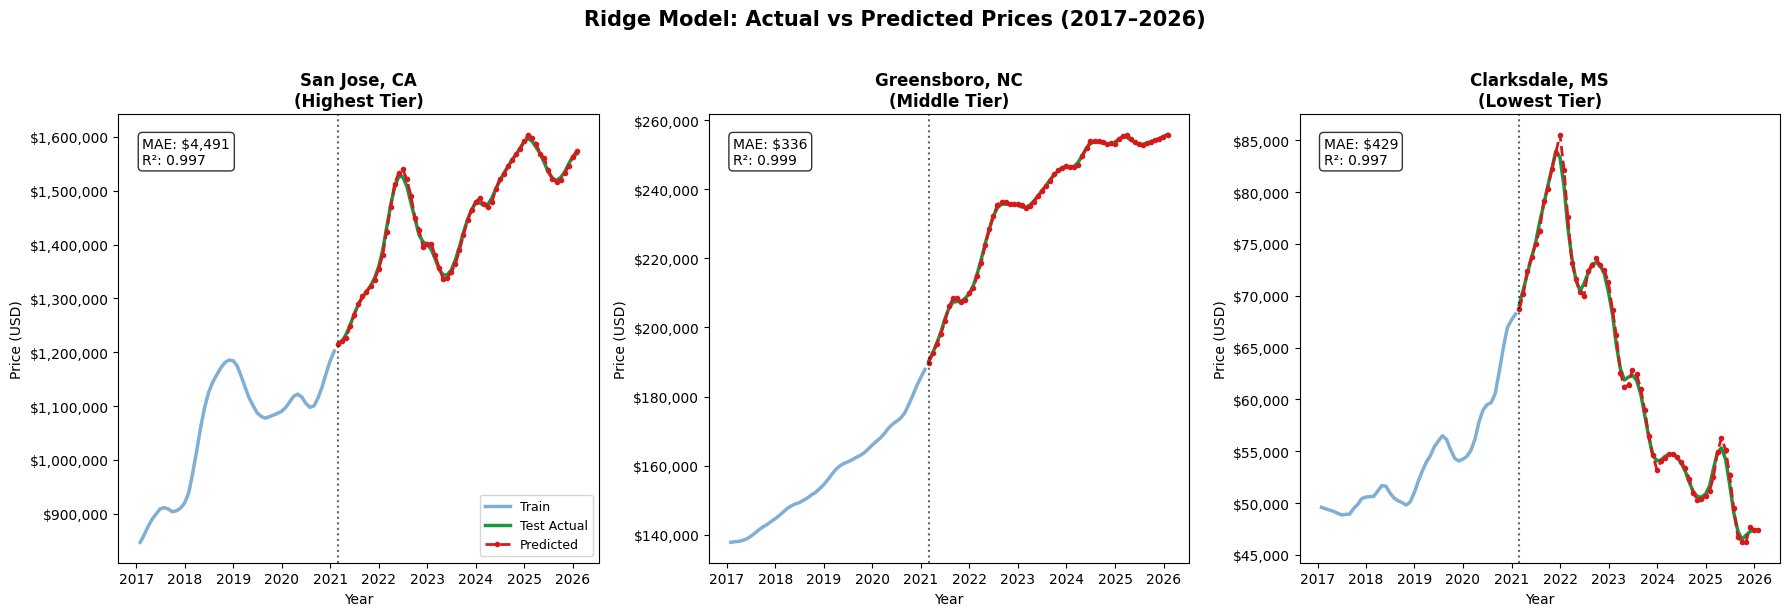

In [112]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Use Ridge model for final forecast
best_model  = grid.best_estimator_
best_scaler = scaler
log_preds   = best_model.predict(X_test_sc)
test_df["predicted_price"] = test_df["price_prev"] * np.exp(log_preds)

# Auto-select 3 representative cities
city_avg = train_df.groupby(["RegionID", "RegionName"])["price"].mean().reset_index()
city_avg = city_avg.sort_values("price", ascending=False).reset_index(drop=True)

targets = [
    (city_avg.iloc[0]["RegionID"],                  city_avg.iloc[0]["RegionName"],                  "Highest Tier"),
    (city_avg.iloc[len(city_avg)//2]["RegionID"],    city_avg.iloc[len(city_avg)//2]["RegionName"],    "Middle Tier"),
    (city_avg.iloc[len(city_avg)-1]["RegionID"],     city_avg.iloc[len(city_avg)-1]["RegionName"],     "Lowest Tier"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
train_df["date_dt"] = pd.to_datetime(train_df["date"])
test_df["date_dt"]  = pd.to_datetime(test_df["date"])

for i, (rid, rname, tier) in enumerate(targets):
    ax = axes[i]
    t_train = train_df[train_df["RegionID"] == rid].copy()
    t_test  = test_df[test_df["RegionID"] == rid].copy()
    t_train = t_train[t_train["date_dt"].dt.year >= 2017]

    local_mae = mean_absolute_error(t_test["price"], t_test["predicted_price"])
    local_r2  = r2_score(t_test["price"], t_test["predicted_price"])

    ax.plot(t_train["date_dt"], t_train["price"], color="#2C7BB6", lw=2.5, alpha=0.6, label="Train")
    ax.plot(t_test["date_dt"],  t_test["price"],  color="#1A9641", lw=2.5, label="Test Actual")
    ax.plot(t_test["date_dt"],  t_test["predicted_price"], color="#D7191C", lw=2, ls="--", marker="o", ms=3, label="Predicted")

    split_dt = t_test["date_dt"].min()
    ax.axvline(split_dt, color="black", ls=":", alpha=0.6)

    ax.set_title(f"{rname}\n({tier})", fontsize=12, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Price (USD)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.text(0.05, 0.95, f"MAE: ${local_mae:,.0f}\nR²: {local_r2:.3f}",
            transform=ax.transAxes, fontsize=10, va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    if i == 0:
        ax.legend(loc="lower right", fontsize=9)

plt.suptitle("Ridge Model: Actual vs Predicted Prices (2017–2026)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---

## 7. Conclusion

### Key Findings

1. **Log-return** is the correct target — it stabilizes variance and enables fair cross-market comparison.
2. **Lag-1 is the strongest predictor** with ~0.91 correlation to the target.
3. **All trained models dramatically outperform the baseline** — Ridge and LightGBM achieve R² ≈ 0.999 with 50-75% lower MAE.
4. **The 2008 housing crisis** and **post-COVID boom** are clearly visible in both SQL analysis and visualizations.
5. **Geographic disparity is extreme**: highest-tier markets (San Jose) average 10x+ more than lowest-tier (Clarksdale).

### Technical Highlights
- **Factory Pattern** preprocessing supports 3 pipeline variants from a single codebase
- **Time-based splitting** prevents data leakage (strict chronological cutoff)
- **City target encoding** fitted on train only, with global mean fallback for unseen cities
- **Plotly visualizations** provide interactive, data-rich EDA charts